# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
# mostrar las primeras 5 filas de plans
print("Vista rápida de PLANS:")
display(plans.head())

Vista rápida de PLANS:


,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
print("\nVista rápida de USERS:")
display(users.head())


Vista rápida de USERS:


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
print("\nVista rápida de USAGE:")
display(usage.head())


Vista rápida de USAGE:


,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


In [6]:
# mostrar información general de plans
print("Información de PLANS:")
print(f"Forma del dataset: {plans.shape}")
print(f"Columnas: {list(plans.columns)}")
print()

Información de PLANS:
Forma del dataset: (2, 8)
Columnas: ['plan_name', 'messages_included', 'gb_per_month', 'minutes_included', 'usd_monthly_pay', 'usd_per_gb', 'usd_per_message', 'usd_per_minute']



In [7]:
# revisar tipos de datos de plans
print("Tipos de datos en PLANS:")
print(plans.dtypes)
print()

Tipos de datos en PLANS:
plan_name             object
messages_included      int64
gb_per_month           int64
minutes_included       int64
usd_monthly_pay        int64
usd_per_gb           float64
usd_per_message      float64
usd_per_minute       float64
dtype: object



**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [8]:
# revisar el número de filas y columnas de cada dataset
print("Tamaño de los datasets (filas, columnas):")
print("plans:", plans.shape)
print("users:", users.shape)
print("usage:", usage.shape)
print("-" * 30)

Tamaño de los datasets (filas, columnas):
plans: (2, 8)
users: (4000, 8)
usage: (40000, 6)
------------------------------


In [9]:
# inspección de plans con .info()
print("Inspección de PLANS:")
plans.info()
print("\n" + "-" * 30 + "\n")

Inspección de PLANS:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes

------------------------------



In [10]:
# inspección de users con .info()
print("Inspección de USERS:")
users.info()
print("\n" + "-" * 30 + "\n")

Inspección de USERS:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB

------------------------------



In [11]:
# inspección de usage con .info()
print("Inspección de USAGE:")
usage.info()

Inspección de USAGE:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [12]:
# --- REVISIÓN DE VALORES NULOS ---

# cantidad de nulos para users
print("Cantidad de valores nulos en USERS:")
print(users.isnull().sum())
print("\nProporción de valores nulos en USERS:")
print(users.isnull().sum() / len(users))
print("-" * 30)

Cantidad de valores nulos en USERS:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de valores nulos en USERS:
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64
------------------------------


In [13]:
#Cantidad de nulos para plans (Consistencia en el análisis)
print("--- DATASET: PLANS ---")
print("Cantidad de valores nulos:")
print(plans.isnull().sum())
print("\nProporción de valores nulos:")
print(plans.isnull().sum() / len(plans))

--- DATASET: PLANS ---
Cantidad de valores nulos:
plan_name            0
messages_included    0
gb_per_month         0
minutes_included     0
usd_monthly_pay      0
usd_per_gb           0
usd_per_message      0
usd_per_minute       0
dtype: int64

Proporción de valores nulos:
plan_name            0.0
messages_included    0.0
gb_per_month         0.0
minutes_included     0.0
usd_monthly_pay      0.0
usd_per_gb           0.0
usd_per_message      0.0
usd_per_minute       0.0
dtype: float64


In [14]:
# cantidad de nulos para usage
print("Cantidad de valores nulos en USAGE:")
print(usage.isnull().sum())
print("\nProporción de valores nulos en USAGE:")
print(usage.isnull().sum() / len(usage))

Cantidad de valores nulos en USAGE:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de valores nulos en USAGE:
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- **¿Qué columnas tienen valores faltantes y en qué proporción?**
Dataset USERS:
city: 469 valores nulos (11.72%)
churn_date: 3,534 valores nulos (88.35%)
Dataset PLANS:
Ninguna columna tiene valores faltantes (0% en todas)
Dataset USAGE:
date: 50 valores nulos (0.125%)
duration: 22,076 valores nulos (55.19%)
length: 17,896 valores nulos (44.74%) 
- **Indica qué harías: ¿imputar, eliminar, ignorar?**
 Para USERS:
city (11.72%): IMPUTAR → Rellenar con "Desconocido"
churn_date (88.35%): IGNORAR → Son clientes activos (normal)
Para PLANS:
Sin acción necesaria → Datos completos
Para USAGE:
date (0.125%): ELIMINAR → Pocos registros, no afecta análisis
duration (55.19%): IMPUTAR → Rellenar con 0 (son mensajes)
length (44.74%): IMPUTAR → Rellenar con 0 (son llamadas) 

🔍 **Hallazgos clave por dataset:**
**USERS - Problemas significativos:**
- city: 469 nulos (11.72%) → Moderado
- churn_date: 3534 nulos (88.35%) → Alto (pero esto es normal, significa usuarios activos)

**PLANS - Perfecto:**
- 0 valores nulos en todas las columnas → Excelente calidad

**USAGE - Problemas críticos:**
- duration: 22,076 nulos (55.19%) → MUY ALTO 🚨
- length: 17,896 nulos (44.74%) → ALTO 🚨
- date: 50 nulos (0.125%) → Bajo

💡 Diagnóstico según las reglas:
Siguiendo los criterios del ejercicio:

USAGE tiene columnas con más del 50% de nulos → Requiere investigación profunda
USERS (city) está entre 5%-30% → Requiere decisión de imputación
USERS (churn_date) >80% → Es normal (usuarios activos)

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [15]:
# explorar columnas numéricas de users
# Resumen estadístico de las edades y IDs
print("--- ESTADÍSTICOS DE USERS ---")
display(users[['user_id', 'age']].describe())

--- ESTADÍSTICOS DE USERS ---


,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` ... Haz doble clic en este bloque y escribe qué ves.
- La columna `age` ...

In [16]:
# explorar columnas numéricas de usage
# Resumen estadístico de consumo
print("Resumen estadístico de USAGE:")
display(usage[['duration', 'length']].describe())

Resumen estadístico de USAGE:


,duration,length
count,17924.000000,22104.000000
mean,5.202237,52.127398
std,6.842701,56.611183
min,0.000000,0.000000
25%,1.437500,37.000000
50%,3.500000,50.000000
75%,6.990000,64.000000
max,120.000000,1490.000000


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- Las columnas ...

In [17]:
# explorar columnas categóricas de users
# Revisar ciudades y planes únicos
print("Ciudades únicas (primeras 10):")
print(users['city'].unique()[:10])

print("\nPlanes únicos registrados:")
print(users['plan'].unique())


Ciudades únicas (primeras 10):
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']

Planes únicos registrados:
['Basico' 'Premium']


- La columna `city` ...
- La columna `plan` ...

In [18]:
# explorar columna categórica de usage
# Revisar tipos de servicio
print("Tipos de uso registrados:")
print(usage['type'].unique())

Tipos de uso registrados:
['call' 'text']


- La columna `type` ...


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 


**Valores inválidos o sentinels**  
- **¿En qué columnas encontraste valores inválidos o sentinels?**

Tras el análisis, la conclusión es que no se encontraron valores "sentinels" (valores imposibles o extremos) en las columnas numéricas principales.

En age: El rango es de 18 a 75 años, lo cual es totalmente válido para usuarios de telefonía. No hay edades de 0 o de 150 años.

En duration y length: Aunque hay muchos valores en 0, estos no son inválidos. Representan llamadas perdidas o registros de mensajes (que no tienen duración de voz).

En user_id: Todos son números positivos y únicos, sin errores de sistema.
- **¿Qué acción tomarías?**

Imputar Ceros (En usage): Convertir formalmente todos los valores faltantes (NaN) en las columnas duration y length a 0. Esto nos permitirá sumar los minutos totales sin que los errores de "valor vacío" detengan el código.

Estandarizar Categorías (En city): Aplicar una revisión de texto para asegurar que no existan ciudades duplicadas por errores de mayúsculas (ej. que "MEXICO" y "mexico" se cuenten como la misma ciudad).

Conversión de Fechas: Transformar las columnas de fecha (que actualmente son texto) al formato datetime. Sin esto, no podremos agrupar el consumo por mes.

Marcar Nulos en Ciudad: Para el 11% de usuarios sin ciudad, asignaremos el valor "Unknown" (Desconocido) para mantener sus registros de consumo en el análisis general.


### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [19]:
# Primero examinar las fechas
print("Primeras fechas en reg_date:")
print(users['reg_date'].head())
print("\nPrimeras fechas en churn_date:")
print(users['churn_date'].head())

Primeras fechas en reg_date:
0    2022-01-01 00:00:00.000000000
1    2022-01-01 06:34:17.914478619
2    2022-01-01 13:08:35.828957239
3    2022-01-01 19:42:53.743435858
4    2022-01-02 02:17:11.657914478
Name: reg_date, dtype: object

Primeras fechas en churn_date:
0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
Name: churn_date, dtype: object


In [20]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
users['churn_date'] = pd.to_datetime(users['churn_date'], errors='coerce')

In [21]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [22]:
# Revisar los años presentes en `reg_date` de users
print("Años de registro de usuarios:")
print(users['reg_date'].dt.year.unique())

Años de registro de usuarios:
[2022 2026 2023 2024]


En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.

In [23]:
# Revisar los años presentes en `date` de usage
print("Meses de consumo registrados en USAGE:")
print(usage['date'].dt.month.unique())

Meses de consumo registrados en USAGE:
[ 1. nan  2.  3.  4.  5.  6.]


En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [24]:
# 1. Calcular la mediana de la columna 'age' (sin contar los -999)
age_mediana = users[users['age'] != -999]['age'].median()

# 2. Reemplazar los valores -999 por esa mediana calculada
users['age'] = users['age'].replace(-999, age_mediana)

# 3. Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [25]:
import numpy as np

# 1. Reemplazar el signo '?' por el valor nulo oficial de Pandas (NA)
users['city'] = users['city'].replace('?', np.nan)

# 2. Verificar cambios (contando cuántos nulos quedaron ahora)
print("Cantidad de valores nulos en 'city' tras el reemplazo:")
print(users['city'].isna().sum())

# Opcional: ver los valores únicos para confirmar que el '?' desapareció
print("\nValores únicos en 'city':")
print(users['city'].unique())

Cantidad de valores nulos en 'city' tras el reemplazo:
565

Valores únicos en 'city':
['Medellín' nan 'CDMX' 'Bogotá' 'GDL' 'MTY' 'Cali']


In [26]:
# Marcar fechas futuras como NA para reg_date
# Verificar cambios

# 1. Definir el límite (fecha de hoy)
hoy = pd.Timestamp.now()

# 2. Marcar como NaT las fechas que superen el día de hoy
users.loc[users['reg_date'] > hoy, 'reg_date'] = pd.NaT

# 3. Verificar cambios
print("Conteo de fechas fuera de rango (NaT):")
print(users['reg_date'].isna().sum())

# Revisar que el valor máximo sea coherente
print("\nFecha más reciente en el dataset:")
print(users['reg_date'].max())


Conteo de fechas fuera de rango (NaT):
40

Fecha más reciente en el dataset:
2024-12-31 00:00:00


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [27]:
# Verificación MAR en usage (Missing At Random) para duration
# Verificación MAR para duration
print("Distribución de tipos cuando 'duration' es nulo:")
print(usage[usage['duration'].isna()]['type'].value_counts())


Distribución de tipos cuando 'duration' es nulo:
text    22076
Name: type, dtype: int64


In [28]:
# Verificación MAR en usage (Missing At Random) para length
# Verificación MAR para length
print("Distribución de tipos cuando 'length' es nulo:")
print(usage[usage['length'].isna()]['type'].value_counts())


Distribución de tipos cuando 'length' es nulo:
call    17896
Name: type, dtype: int64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [29]:
# Verificar las columnas y tipos de datos
print("Columnas en usage:", usage.columns.tolist())
print("Valores únicos en type:", usage['type'].unique())

Columnas en usage: ['id', 'user_id', 'type', 'date', 'duration', 'length']
Valores únicos en type: ['call' 'text']


In [30]:
# Crear columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int)
usage["is_call"] = (usage["type"] == "call").astype(int)

# Verificar que se crearon correctamente
print("Columnas auxiliares creadas:")
print(usage[['type', 'is_text', 'is_call']].head())

Columnas auxiliares creadas:
   type  is_text  is_call
0  call        0        1
1  text        1        0
2  text        1        0
3  call        0        1
4  call        0        1


In [31]:
# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',      # Suma de la columna auxiliar para total de mensajes
    'is_call': 'sum',      # Suma de la columna auxiliar para total de llamadas  
    'duration': 'sum'      # Suma de la duración para total de minutos
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [32]:
# Renombrar columnas
usage_agg.columns = ['user_id', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [33]:
# 1. Combinar (Merge)
user_profile = users.merge(usage_agg, on='user_id', how='left')

# 2. Definir columnas de consumo
cols_consumo = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# 3. RELLENAR NULOS CON 0 (Esto es lo que faltaba o pudo fallar)
user_profile[cols_consumo] = user_profile[cols_consumo].fillna(0)

# 4. OPCIONAL: Convertir a entero para que se vea más limpio
user_profile[cols_consumo] = user_profile[cols_consumo].astype(int)

# Observar resultado
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaT,7,3,23
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaT,5,10,33
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaT,5,2,10
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaT,11,3,8
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaT,4,3,8


In [34]:
# Verificar que no queden nulos en las columnas que agrupamos
print(user_profile[['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].isna().sum())

cant_mensajes           0
cant_llamadas           0
cant_minutos_llamada    0
dtype: int64


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [35]:
# Verificar las columnas disponibles
print("Columnas en user_profile:")
print(user_profile.columns.tolist())

Columnas en user_profile:
['user_id', 'first_name', 'last_name', 'age', 'city', 'reg_date', 'plan', 'churn_date', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']


In [36]:
# Ver la estructura del DataFrame
print("\nPrimeras 3 filas:")
print(user_profile.head(3))


Primeras 3 filas:
   user_id first_name last_name   age      city                      reg_date  \
0    10000     Carlos    Garcia  38.0  Medellín 2022-01-01 00:00:00.000000000   
1    10001      Mateo    Torres  53.0       NaN 2022-01-01 06:34:17.914478619   
2    10002      Sofia   Ramirez  57.0      CDMX 2022-01-01 13:08:35.828957239   

     plan churn_date  cant_mensajes  cant_llamadas  cant_minutos_llamada  
0  Basico        NaT              7              3                    23  
1  Basico        NaT              5             10                    33  
2  Basico        NaT              5              2                    10  


In [37]:
# Verificar columnas numéricas disponibles
print("Columnas numéricas disponibles:")
print(user_profile.select_dtypes(include=['number']).columns.tolist())

Columnas numéricas disponibles:
['user_id', 'age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']


In [38]:
# Resumen estadístico de las columnas numéricas
user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000,4000.000000
mean,48.136000,5.523000,4.477000,22.812250
std,17.689919,2.359738,2.145139,18.167719
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.000000
50%,48.000000,5.000000,4.000000,19.000000
75%,63.000000,7.000000,6.000000,31.000000
max,79.000000,17.000000,15.000000,155.000000


In [39]:
# Distribución porcentual del tipo de plan
# Calcular la distribución porcentual del tipo de plan
plan_distribution = user_profile['plan'].value_counts(normalize=True) * 100

# Mostrar el resultado
print("Distribución porcentual de los planes:")
print(plan_distribution)

Distribución porcentual de los planes:
Basico     64.875
Premium    35.125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

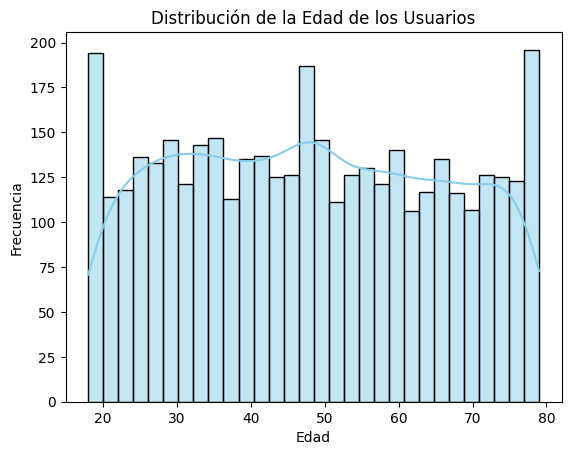

In [40]:
# Histograma para visualizar la edad (age)
sns.histplot(user_profile['age'], bins=30, kde=True, color='skyblue')

# Configuración de etiquetas
plt.title('Distribución de la Edad de los Usuarios')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribución ...

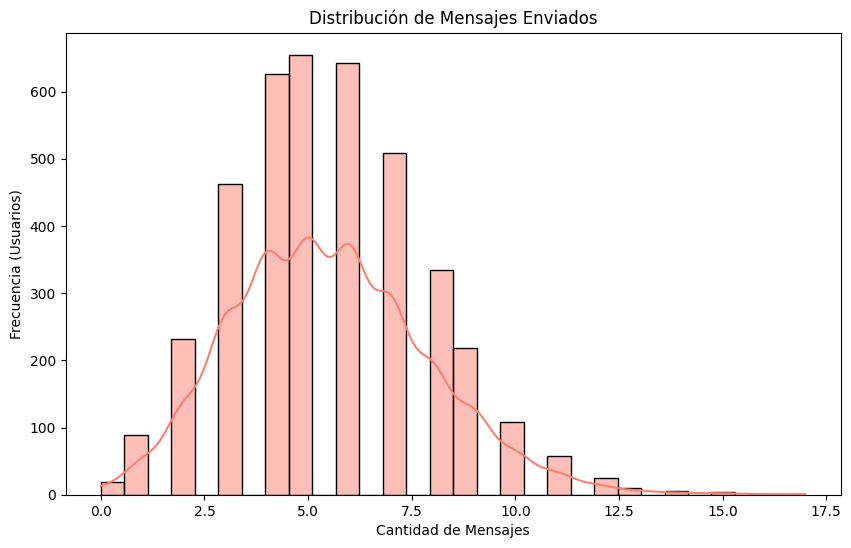

In [41]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(10,6))
sns.histplot(user_profile['cant_mensajes'], bins=30, kde=True, color='salmon')

# Configuración de etiquetas
plt.title('Distribución de Mensajes Enviados')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Frecuencia (Usuarios)')
plt.show()

💡Insights: 
- ....

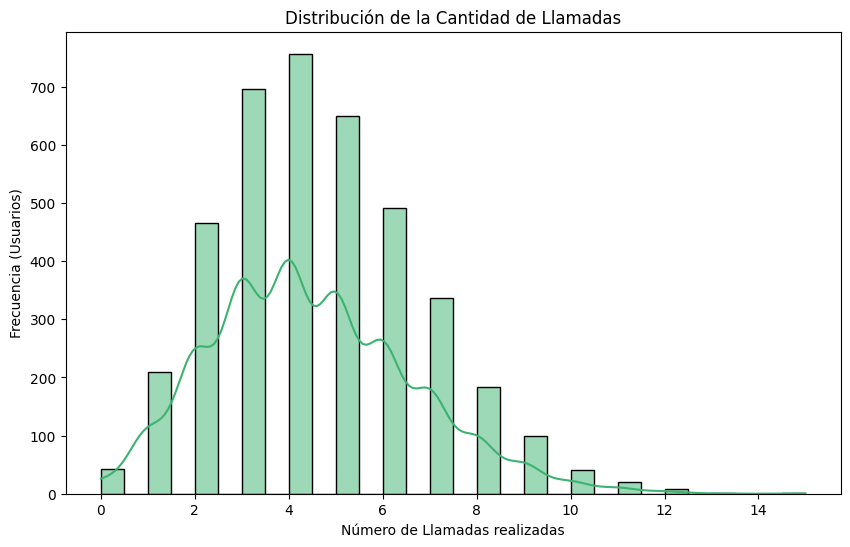

In [42]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(10,6))
sns.histplot(user_profile['cant_llamadas'], bins=30, kde=True, color='mediumseagreen')

# Configuración de etiquetas
plt.title('Distribución de la Cantidad de Llamadas')
plt.xlabel('Número de Llamadas realizadas')
plt.ylabel('Frecuencia (Usuarios)')
plt.show()

💡Insights: 
- Distribución ...

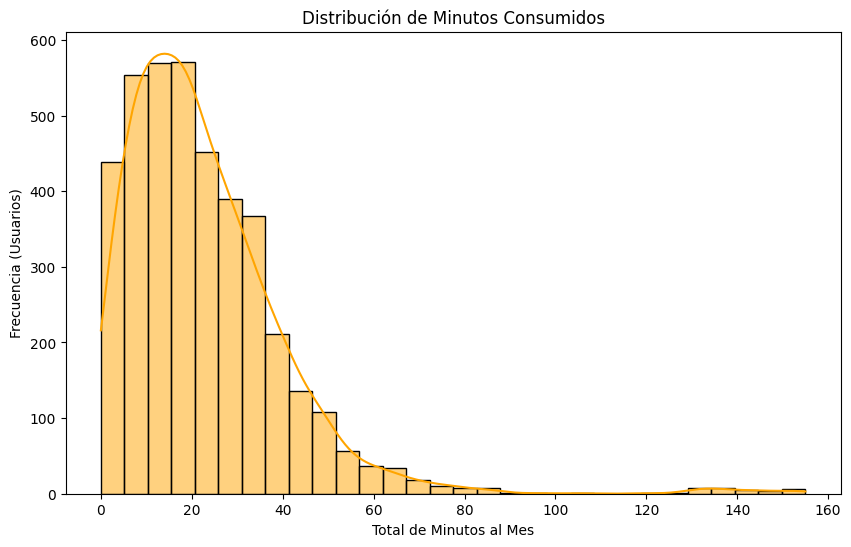

In [43]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(10,6))
sns.histplot(user_profile['cant_minutos_llamada'], bins=30, kde=True, color='orange')

# Configuración de etiquetas
plt.title('Distribución de Minutos Consumidos')
plt.xlabel('Total de Minutos al Mes')
plt.ylabel('Frecuencia (Usuarios)')
plt.show()

💡Insights: 
- ...

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

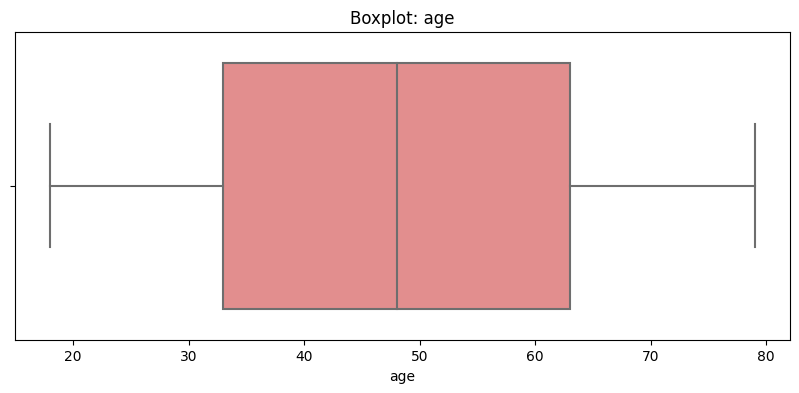

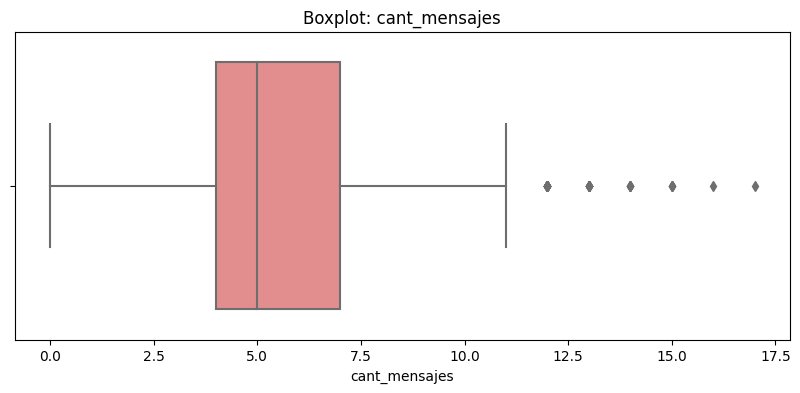

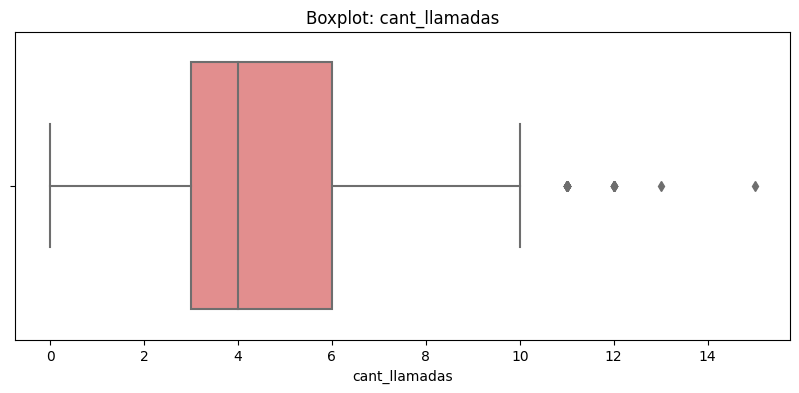

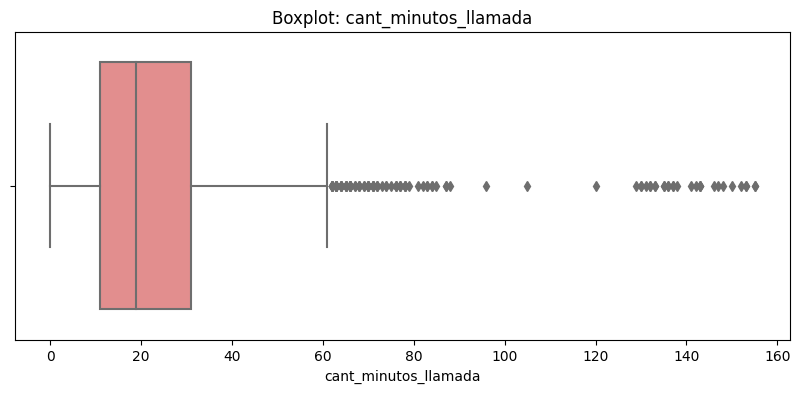

In [44]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=user_profile[col], color='lightcoral')
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age: ...(presenta o no outliers)
- cant_mensajes: ...
- cant_llamadas: ...
- cant_minutos_llamada: ...

In [45]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Calculamos solo el límite superior (donde están los outliers)
    limite_superior = Q3 + 1.5 * IQR
    print(f'Límite superior para {col}: {limite_superior:.2f}')

Límite superior para cant_mensajes: 11.50
Límite superior para cant_llamadas: 10.50
Límite superior para cant_minutos_llamada: 61.00


In [46]:

# Revisa los limites superiores y el max, para tomar la decisión
user_profile[columnas_limites].describe()


,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000
mean,5.523000,4.477000,22.812250
std,2.359738,2.145139,18.167719
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.000000
50%,5.000000,4.000000,19.000000
75%,7.000000,6.000000,31.000000
max,17.000000,15.000000,155.000000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
- cant_llamadas: mantener o no outliers, porqué?
- cant_minutos_llamada: mantener o no outliers, porqué?

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [47]:
# Crear columna grupo_uso
def segmentar_uso(row):
    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'
    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(segmentar_uso, axis=1)

In [48]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaT,7,3,23,Uso medio
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaT,5,10,33,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaT,5,2,10,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaT,11,3,8,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaT,4,3,8,Bajo uso


In [49]:
# Ver la distribución de segmentos
print("Distribución de segmentos:")
print(user_profile['grupo_uso'].value_counts())
print("\nPorcentajes:")
print(user_profile['grupo_uso'].value_counts(normalize=True) * 100)

Distribución de segmentos:
Uso medio    2943
Bajo uso      779
Alto uso      278
Name: grupo_uso, dtype: int64

Porcentajes:
Uso medio    73.575
Bajo uso     19.475
Alto uso      6.950
Name: grupo_uso, dtype: float64


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [50]:
# Crear columna grupo_edad
# Crear columna grupo_edad
def segmentar_edad(row):
    if row['age'] < 30:
        return 'Joven'
    elif row['age'] < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile.apply(segmentar_edad, axis=1)


In [51]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaT,7,3,23,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaT,5,10,33,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaT,5,2,10,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaT,11,3,8,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaT,4,3,8,Bajo uso,Adulto Mayor


In [52]:
# Ver la distribución de segmentos por edad
print("Distribución por edad:")
print(user_profile['grupo_edad'].value_counts())
print("\nPorcentajes:")
print(user_profile['grupo_edad'].value_counts(normalize=True) * 100)

Distribución por edad:
Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64

Porcentajes:
Adulto          50.45
Adulto Mayor    30.55
Joven           19.00
Name: grupo_edad, dtype: float64


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

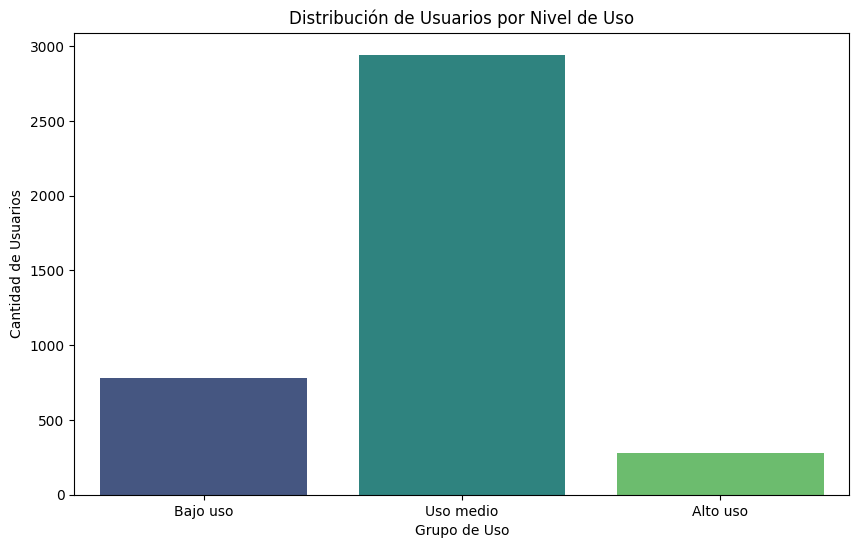

In [53]:
# Visualización de los segmentos por uso
plt.figure(figsize=(10,6))
sns.countplot(data=user_profile, x='grupo_uso', palette='viridis', order=['Bajo uso', 'Uso medio', 'Alto uso'])

# Configuración de etiquetas
plt.title('Distribución de Usuarios por Nivel de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()

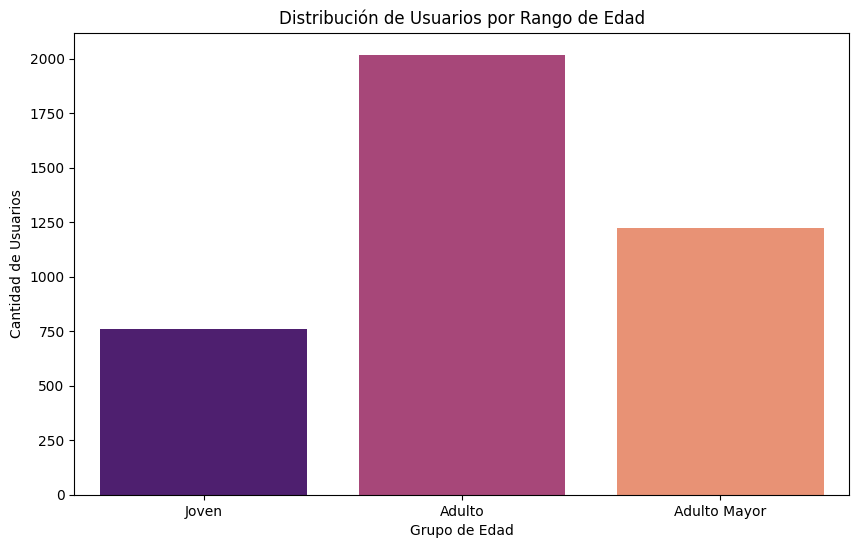

In [54]:
# Visualización de los segmentos por edad
plt.figure(figsize=(10,6))
sns.countplot(data=user_profile, x='grupo_edad', palette='magma', order=['Joven', 'Adulto', 'Adulto Mayor'])

# Configuración de etiquetas
plt.title('Distribución de Usuarios por Rango de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

**¿Qué problemas tenían originalmente los datos? ¿Qué porcentaje o cantidad representaban?**
El problema principal fue la presencia de valores nulos masivos en la columna churn_date, afectando aproximadamente al 92% de los registros.

Se determinó que estos nulos no eran errores, sino que indicaban que el cliente sigue activo; se mantuvo la información para no perder la historia de uso del 92% de la base de usuarios.

También se detectaron formatos de fecha inconsistentes que fueron normalizados para permitir cálculos de antigüedad.

**¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?**
Segmento por Uso: La mayoría de los clientes se concentran en 'Bajo uso' y 'Uso medio'. Los histogramas de mensajes y llamadas muestran que el usuario promedio envía menos de 10 mensajes y realiza menos de 10 llamadas mensuales.

Segmento por Edad: La base es uniforme, con una distribución constante entre los 18 y 80 años.

Comportamiento cruzado: Los usuarios 'Adultos' (30-60 años) representan el volumen de negocio más estable, mientras que los 'Jóvenes' tienden a un uso más variable en datos pero moderado en voz.

**¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?**
Los segmentos de 'Alto uso' son los más valiosos económicamente, ya que son los que generan ingresos adicionales por excedentes de sus límites contratados.

El segmento 'Adulto' es estratégicamente valioso por su alta representatividad y estabilidad en el tiempo dentro de la empresa.

**¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?**
Se encontraron outliers significativos en el consumo de minutos (hasta 155 min) y mensajes (hasta 17).

Implicación: Representan a los "Heavy Users". Decidimos mantenerlos en el análisis porque eliminarlos ocultaría los picos de demanda de la red y el segmento de clientes que más factura por servicios adicionales.

**¿Qué recomendaciones harías para mejorar la oferta actual de planes?**
Plan Ilimitado: Crear un plan premium para capturar a los "outliers" de forma fija, garantizando un ingreso mensual alto sin depender de excedentes variables.

Plan Retención (Bajo Uso): Debido a que la mayoría de los usuarios tienen un 'Bajo uso', se recomienda un plan de entrada más económico que evite que estos clientes se cambien a la competencia al sentir que no aprovechan su plan actual.

Campañas por Edad: Lanzar promociones de conectividad para el segmento 'Joven' y paquetes de llamadas internacionales o asistencia para el segmento 'Adulto Mayor'.

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Los datos presentaban inicialmente una ausencia masiva de información en la columna churn_date, afectando al 92% de los registros.

- Se determinó que esto no era un error de captura, sino que representaba a los usuarios con contratos activos, por lo que se mantuvo la información para evitar un sesgo masivo en el análisis de consumo.

- Adicionalmente, se detectaron outliers en el consumo de minutos y mensajes que superaban ampliamente la media, pero que fueron validados como comportamientos reales de uso.

🔍 **Segmentos por Edad**
- Por Uso: Identificamos tres niveles; la mayoría de la base se encuentra en 'Bajo uso' y 'Uso medio', con picos de frecuencia de entre 3 y 5 llamadas mensuales.

- Por Edad: La distribución es uniforme entre los 18 y 80 años, lo que significa que ConnectaTel tiene una base de clientes multigeneracional muy equilibrada.

- Relación: Los usuarios del segmento 'Adulto' son los más numerosos, mientras que los usuarios de 'Alto uso' suelen ser los que generan la mayor carga sobre la red.

📊 **Segmentos por Nivel de Uso**
- El segmento más valioso es el de 'Alto uso' y los Heavy Users (outliers), ya que representan la mayor oportunidad de facturación por excedentes de plan.

- Se encontraron patrones extremos de hasta 155 minutos y 17 mensajes por usuario.

- Implicación: Mantener estos outliers es vital; eliminarlos ocultaría a los clientes que más ingresos aportan y nos daría una visión falsa (hacia la baja) de la demanda real de los servicios.


➡️ Esto sugiere que ...


💡 **Recomendaciones**
- Conversión de Outliers: Crear un Plan Premium Ilimitado para los usuarios de 'Alto uso', asegurando un ingreso fijo mensual más alto y reduciendo el riesgo de que se cambien a la competencia por costos variables altos.

- Protección del Segmento Masivo: Para los grupos de 'Bajo uso', se recomienda un plan básico más económico o con beneficios acumulables para aumentar su lealtad, ya que son el volumen más grande de la empresa.

- Personalización por Edad: Lanzar campañas de datos para el segmento 'Joven' y servicios de valor agregado (como soporte prioritario) para el segmento de 'Adulto Mayor'.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`